# TFT laden & auswerten (ohne Neu-Training)

Dieses Notebook laedt ein **bereits trainiertes und gespeichertes** TFT-Modell (aus
`15_TFT_final_v8.ipynb`, gespeichert per `nf.save(...)`) und stellt die Auswertungs-Werkzeuge
(Walk-Forward-Horizontvergleich, `vergleiche_tft()`-Plot) bereit, **ohne** dass neu trainiert wird.

**Voraussetzung:** Der Ordner mit dem gespeicherten Modell (`MODELL_DIR` unten) muss existieren
(z. B. `../models/tft_final_multivariat` oder `..._v2` fuer das Optuna-getunte Modell).

**Wichtig:** Die Stationsauswahl (`STATIONEN_TEST`) unten muss **exakt** zu den Stationen passen,
mit denen das geladene Modell trainiert wurde -- sonst passt der statische Kovariat
(`stat_exog_list=['stationstyp']`) nicht zum Modell.

## 0. Konfiguration -- hier ggf. anpassen

In [1]:
import warnings; warnings.filterwarnings('ignore')
import os, gc
import numpy as np
import pandas as pd
import torch
import holidays
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from neuralforecast import NeuralForecast

torch.set_float32_matmul_precision('high')

# --- Pfade -----------------------------------------------------------------------------------------
DATA_DIR   = Path('../data/prepared_chronos/behandelt')

# Welches gespeicherte Modell geladen werden soll -- Basis-Modell oder das Optuna-getunte '_v2':
MODELL_DIR = Path('../models/tft_final_multivariat_v2')
# MODELL_DIR = Path('../models/tft_final_multivariat_v2')   # <- alternativ das getunte Modell

ERGEBNIS_CSV = Path('../data/ergebnis_tft_final_geladen.csv')

# --- Zeitraum / Horizonte (MUSS zum Training passen) -----------------------------------------------
TRAIN_CUTOFF  = '2016-08-30'
FREQ          = 'h'
HORIZONTE     = [8, 24, 48, 72]
H_TFT         = max(HORIZONTE)
INPUT_SIZE    = 336              # muss zum geladenen Modell passen (siehe ggf. FIX_INPUT_SIZE bei _v2)

# --- Regressoren (MUESSEN zum Training passen) ------------------------------------------------------
WETTER_REGRESSOREN        = ['TEMP', 'DEWP', 'PRES', 'WSPM', 'RAIN', 'wd_sin', 'wd_cos']
KALENDER_REGRESSOREN      = ['hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'feiertag']
REGRESSOREN_ZUKUNFT       = WETTER_REGRESSOREN + KALENDER_REGRESSOREN
REGRESSOREN_VERGANGENHEIT = ['SO2', 'NO2', 'CO', 'O3']
REGRESSOREN_ZU_SKALIEREN  = WETTER_REGRESSOREN[:-2] + REGRESSOREN_VERGANGENHEIT

print('GPU verfuegbar:', torch.cuda.is_available())

GPU verfuegbar: True


## 1. Stationen: Auswahl + Stationstyp (statischer Kovariat)

Muss zur Stationsauswahl beim Training des geladenen Modells passen (Reihenfolge/Kodierung von
`stationstyp` eingeschlossen).

In [3]:
ALLE_STATIONEN = sorted(p.name.replace('chronos_', '').replace('.csv', '')
                       for p in DATA_DIR.glob('chronos_*.csv'))
#ALLE_STATIONEN = [s for s in ALLE_STATIONEN if s != 'Aotizhongxin']   # Datenluecke -> ausgeschlossen
ALLE_STATIONEN = [s for s in ALLE_STATIONEN]   # Datenluecke -> ausgeschlossen
# --- Modell wurde auf ALLEN Stationen trainiert -------------------------------------------------------
STATIONEN_TEST = ALLE_STATIONEN
print(f'Verwendet ({len(STATIONEN_TEST)} Stationen): {STATIONEN_TEST}')

STATIONSTYP_TEXT = {
    'Changping':      'Vorstadt/Hintergrund',
    'Dingling':       'Vorstadt/Hintergrund',
    'Dongsi':         'Urban',
    'Guanyuan':       'Urban',
    'Gucheng':        'Urban/Industrienah',
    'Huairou':        'Vorstadt/Hintergrund',
    'Nongzhanguan':   'Urban',
    'Shunyi':         'Vorstadt',
    'Tiantan':        'Urban/Park',
    'Wanliu':         'Urban',
    'Wanshouxigong':  'Urban',
    'Aotizhongxin':  'Urban',
}
STATIONSTYP_CODE = {
    'Urban': 0, 'Urban/Park': 0, 'Urban/Industrienah': 0,
    'Vorstadt/Hintergrund': 1, 'Vorstadt': 1,
}

stat_df = pd.DataFrame({
    'unique_id': STATIONEN_TEST,
    'stationstyp': [float(STATIONSTYP_CODE[STATIONSTYP_TEXT[s]]) for s in STATIONEN_TEST],
})
print()
print(stat_df.to_string(index=False))

Verwendet (12 Stationen): ['Aotizhongxin', 'Changping', 'Dingling', 'Dongsi', 'Guanyuan', 'Gucheng', 'Huairou', 'Nongzhanguan', 'Shunyi', 'Tiantan', 'Wanliu', 'Wanshouxigong']

    unique_id  stationstyp
 Aotizhongxin          0.0
    Changping          1.0
     Dingling          1.0
       Dongsi          0.0
     Guanyuan          0.0
      Gucheng          0.0
      Huairou          1.0
 Nongzhanguan          0.0
       Shunyi          1.0
      Tiantan          0.0
       Wanliu          0.0
Wanshouxigong          0.0


## 2. Daten laden, regularisieren, log-transformieren, standardisieren

Identisch zur Vorverarbeitung im Trainings-Notebook -- wird hier **nur fuer die Auswertung**
gebraucht (Kontextfenster, echte Werte zum Vergleich, MASE-Skala), das Modell selbst wird nicht
neu trainiert.

In [4]:
def lade_gesamt(station):
    df = pd.read_csv(DATA_DIR / f'chronos_{station}.csv', parse_dates=['ds'])
    return df.sort_values('ds').reset_index(drop=True)

def regularize(df, spalten):
    d = df.set_index('ds').sort_index()
    d = d.reindex(pd.date_range(d.index.min(), d.index.max(), freq=FREQ))
    for c in spalten:
        d[c] = d[c].interpolate(limit_direction='both')
    d.index.name = 'ds'
    return d.reset_index()

_CN_HOLIDAYS = holidays.country_holidays('CN', years=range(2013, 2018))

def add_feiertag(df):
    d = df.copy()
    d['feiertag'] = d['ds'].dt.date.astype('O').map(lambda t: 1 if t in _CN_HOLIDAYS else 0)
    return d

def add_time_features(df):
    d = df.copy()
    d['hour_sin'] = np.sin(2*np.pi*d['ds'].dt.hour/24); d['hour_cos'] = np.cos(2*np.pi*d['ds'].dt.hour/24)
    d['day_sin']  = np.sin(2*np.pi*d['ds'].dt.dayofyear/365.25); d['day_cos'] = np.cos(2*np.pi*d['ds'].dt.dayofyear/365.25)
    return d

def mae(y, yh):  return float(np.mean(np.abs(np.asarray(y,float)-np.asarray(yh,float))))
def rmse(y, yh): return float(np.sqrt(np.mean((np.asarray(y,float)-np.asarray(yh,float))**2)))
def mape(y, yh):
    y=np.asarray(y,float); yh=np.asarray(yh,float); m=y>0
    return float(np.mean(np.abs((y[m]-yh[m])/y[m]))*100) if m.any() else np.nan
def mase_skala(train_y, mp=24):
    a=np.asarray(train_y,float); return float(np.nanmean(np.abs(a[mp:]-a[:-mp])))

alle_spalten = ['y'] + WETTER_REGRESSOREN + REGRESSOREN_VERGANGENHEIT

teile = []
skalen = {}
letzte_ds = []
for st in STATIONEN_TEST:
    d = lade_gesamt(st)
    d = regularize(d, spalten=alle_spalten)
    d = add_time_features(d)
    d = add_feiertag(d)
    d = d[['ds'] + alle_spalten + KALENDER_REGRESSOREN].copy()
    d.insert(0, 'unique_id', st)

    train_maske = d['ds'] < pd.Timestamp(TRAIN_CUTOFF)
    skalen[st] = mase_skala(d.loc[train_maske, 'y'])
    letzte_ds.append(d['ds'].max())

    teile.append(d)

multi = pd.concat(teile, ignore_index=True)

DATENENDE = min(letzte_ds)
multi = multi[multi['ds'] <= DATENENDE].reset_index(drop=True)

print('Stationen:', STATIONEN_TEST)
print('Trainings-Cutoff:', TRAIN_CUTOFF)
print('Gemeinsames Datenende:', DATENENDE)
print(f'Zeilen gesamt: {len(multi)}  |  je Station: {len(multi) // len(STATIONEN_TEST)}')

multi['y_original'] = multi['y']
multi['y'] = np.log1p(multi['y'])

train_maske = multi['ds'] < pd.Timestamp(TRAIN_CUTOFF)
scaler = StandardScaler()
scaler.fit(multi.loc[train_maske, REGRESSOREN_ZU_SKALIEREN])
multi[REGRESSOREN_ZU_SKALIEREN] = scaler.transform(multi[REGRESSOREN_ZU_SKALIEREN])

print('\nSkalierte Regressoren:', REGRESSOREN_ZU_SKALIEREN)
print('MASE-Skalen je Station:', {k: round(v, 2) for k, v in skalen.items()})

Stationen: ['Aotizhongxin', 'Changping', 'Dingling', 'Dongsi', 'Guanyuan', 'Gucheng', 'Huairou', 'Nongzhanguan', 'Shunyi', 'Tiantan', 'Wanliu', 'Wanshouxigong']
Trainings-Cutoff: 2016-08-30
Gemeinsames Datenende: 2017-02-28 23:00:00
Zeilen gesamt: 420768  |  je Station: 35064

Skalierte Regressoren: ['TEMP', 'DEWP', 'PRES', 'WSPM', 'RAIN', 'SO2', 'NO2', 'CO', 'O3']
MASE-Skalen je Station: {'Aotizhongxin': 57.51, 'Changping': 51.41, 'Dingling': 51.17, 'Dongsi': 60.66, 'Guanyuan': 56.72, 'Gucheng': 56.97, 'Huairou': 50.17, 'Nongzhanguan': 60.82, 'Shunyi': 57.71, 'Tiantan': 57.42, 'Wanliu': 57.93, 'Wanshouxigong': 60.39}


## 3. Gespeichertes Modell laden

Hier passiert **kein Training** -- `NeuralForecast.load()` liest die Gewichte + Hyperparameter aus
`MODELL_DIR` (siehe Konfiguration oben).

In [6]:
assert MODELL_DIR.exists(), (
    f'Modell-Ordner {MODELL_DIR} nicht gefunden -- Pfad in Zelle "Konfiguration" oben pruefen/anpassen.'
)

nf = NeuralForecast.load(path=str(MODELL_DIR))
print(f'Modell geladen aus: {MODELL_DIR}')
print('hist_exog_list:', nf.models[0].hist_exog_list)
print('futr_exog_list:', nf.models[0].futr_exog_list)
print('stat_exog_list:', nf.models[0].stat_exog_list)

Seed set to 1


Modell geladen aus: ..\models\tft_final_multivariat_v2
hist_exog_list: ['SO2', 'NO2', 'CO', 'O3']
futr_exog_list: ['TEMP', 'DEWP', 'PRES', 'WSPM', 'RAIN', 'wd_sin', 'wd_cos', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'feiertag']
stat_exog_list: ['stationstyp']


## 4. Lernkurve des geladenen Modells (falls vorhanden)

`train_trajectories`/`valid_trajectories` sitzen auf dem Modell und werden mitgespeichert/geladen
(sofern sie beim Training erfolgreich geloggt wurden).

In [7]:
def plotte_lernkurve(model=None):
    model = model or nf.models[0]
    if not model.train_trajectories:
        print('Keine Trainings-Loss-Historie vorhanden (model.train_trajectories ist leer).')
        return
    train_steps, train_losses = zip(*model.train_trajectories)
    valid_steps, valid_losses = zip(*model.valid_trajectories)

    plt.figure(figsize=(9, 4.5))
    plt.plot(train_steps, train_losses, color='#1C7293', alpha=0.6, lw=1, label='Trainings-Loss (je Step)')
    if valid_steps:
        plt.plot(valid_steps, valid_losses, color='#C4471C', marker='o', ms=4, lw=1.5,
                 label='Validierungs-Loss (je Check)')
    plt.xlabel('Trainings-Step'); plt.ylabel('Loss (MQLoss)')
    plt.title('TFT Lernkurve (geladenes Modell)')
    plt.legend(loc='best'); plt.tight_layout(); plt.show()

plotte_lernkurve()

Keine Trainings-Loss-Historie vorhanden (model.train_trajectories ist leer).


## 5. Horizont-Vergleich (walk-forward, Schritt = 72h) auf dem zurueckgehaltenen Zeitraum

Nutzt ausschliesslich `nf.predict()` mit dem geladenen Modell -- kein erneutes Training. Kann je
nach Testzeitraum/Stationsanzahl ein paar Minuten dauern.

In [8]:
fold_start_daten = []
_t = pd.Timestamp(TRAIN_CUTOFF)
while _t + pd.Timedelta(hours=H_TFT) <= DATENENDE:
    fold_start_daten.append(_t)
    _t += pd.Timedelta(hours=H_TFT)
print(f'{len(fold_start_daten)} Walk-Forward-Fenster von {TRAIN_CUTOFF} bis {DATENENDE.date()}')

alle_vorhersagen = []
for i, cutoff in enumerate(fold_start_daten):
    kontext_start = cutoff - pd.Timedelta(hours=INPUT_SIZE + 24)
    kontext_df = multi[(multi['ds'] >= kontext_start) & (multi['ds'] < cutoff)]
    fenster    = multi[(multi['ds'] >= cutoff) & (multi['ds'] < cutoff + pd.Timedelta(hours=H_TFT))]
    if fenster.empty or fenster['unique_id'].nunique() < len(STATIONEN_TEST):
        continue

    futr_df = fenster[['unique_id', 'ds'] + REGRESSOREN_ZUKUNFT]
    pred = nf.predict(df=kontext_df, static_df=stat_df, futr_df=futr_df)
    pred['yhat'] = np.expm1(pred['TFT-median']).clip(lower=0)
    pred['cutoff'] = cutoff

    echte = fenster[['unique_id', 'ds', 'y_original']].rename(columns={'y_original': 'y'})
    vergleich = echte.merge(pred[['unique_id', 'ds', 'cutoff', 'yhat']], on=['unique_id', 'ds'])
    alle_vorhersagen.append(vergleich)

    if (i + 1) % 10 == 0 or i == len(fold_start_daten) - 1:
        print(f'  Fenster {i+1}/{len(fold_start_daten)} ({cutoff.date()}) erledigt')

cv = pd.concat(alle_vorhersagen, ignore_index=True)
cv['lead'] = ((cv['ds'] - cv['cutoff']).dt.total_seconds() // 3600).astype(int)
print(f'\n{len(cv)} Vorhersage-Zeilen gesamt.')

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


60 Walk-Forward-Fenster von 2016-08-30 bis 2017-02-28


Predicting: |          | 0/? [00:00<?, ?it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

...

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

  Fenster 60/60 (2017-02-23) erledigt

51840 Vorhersage-Zeilen gesamt.


In [9]:
rows = []
for b in HORIZONTE:
    w = cv[cv['lead'] <= b]
    per_station = [{'MAE': mae(g['y'], g['yhat']), 'RMSE': rmse(g['y'], g['yhat']),
                    'MASE': mae(g['y'], g['yhat']) / skalen[st], 'MAPE %': mape(g['y'], g['yhat'])}
                   for st, g in w.groupby('unique_id')]
    m = pd.DataFrame(per_station).mean()
    rows.append({'Modell': f'TFT geladen ({MODELL_DIR.name})', 'Horizont': f'{b} h',
                 'MAE': m['MAE'], 'RMSE': m['RMSE'], 'MASE': m['MASE'], 'MAPE %': m['MAPE %']})

ergebnis_tft = pd.DataFrame(rows)[['Modell', 'Horizont', 'MAE', 'RMSE', 'MASE', 'MAPE %']].round(3)
print(ergebnis_tft.to_string(index=False))

ERGEBNIS_CSV.parent.mkdir(parents=True, exist_ok=True)
ergebnis_tft.to_csv(ERGEBNIS_CSV, index=False)
print(f'\ngespeichert -> {ERGEBNIS_CSV}')

                                Modell Horizont    MAE   RMSE  MASE  MAPE %
TFT geladen (tft_final_multivariat_v2)      8 h 26.640 42.179 0.471  61.272
TFT geladen (tft_final_multivariat_v2)     24 h 31.079 50.585 0.551  66.952
TFT geladen (tft_final_multivariat_v2)     48 h 37.103 64.322 0.657  74.566
TFT geladen (tft_final_multivariat_v2)     72 h 38.496 64.677 0.682  79.735

gespeichert -> ..\data\ergebnis_tft_final_geladen.csv


## 6. Vergleichsplot: echte Werte vs. TFT-Prognose fuer ein beliebiges Split-Datum

`vergleiche_tft(station, split_datum, horizont=H_TFT)` -- funktioniert fuer jede Station in
`STATIONEN_TEST` und jedes Datum, fuer das genug Kontext (`INPUT_SIZE` Stunden davor) und ein
volles Testfenster (danach) vorliegen.

In [10]:
def vergleiche_tft(station, split_datum, horizont=H_TFT, nf=nf, multi=multi, stat_df=stat_df,
                   input_size=INPUT_SIZE, farbe_echt='#3A4148', farbe_modell='#7B2CBF'):
    '''Plottet echte PM2.5-Werte vs. TFT-Prognose fuer `station` ab `split_datum` (`horizont` Stunden)
    und gibt (vergleich_df, mae_wert) zurueck. Gibt den MAE zusaetzlich aus.'''
    split_datum = pd.Timestamp(split_datum)
    kontext_start = split_datum - pd.Timedelta(hours=input_size + 24)

    kontext_df = multi[(multi['unique_id'] == station) &
                       (multi['ds'] >= kontext_start) & (multi['ds'] < split_datum)]
    fenster = multi[(multi['unique_id'] == station) &
                    (multi['ds'] >= split_datum) & (multi['ds'] < split_datum + pd.Timedelta(hours=horizont))]

    if kontext_df.empty:
        raise ValueError(f'Kein Kontext vor {split_datum.date()} fuer Station {station} verfuegbar.')
    if fenster.empty:
        raise ValueError(f'Kein Testfenster ab {split_datum.date()} fuer Station {station} verfuegbar '
                         f'(Datenende: {multi["ds"].max()}).')

    stat_zeile = stat_df[stat_df['unique_id'] == station]
    futr_df = fenster[['unique_id', 'ds'] + REGRESSOREN_ZUKUNFT]
    pred = nf.predict(df=kontext_df, static_df=stat_zeile, futr_df=futr_df)
    pred['yhat'] = np.expm1(pred['TFT-median']).clip(lower=0)
    if 'TFT-lo-80.0' in pred.columns:
        pred['yhat_lo'] = np.expm1(pred['TFT-lo-80.0']).clip(lower=0)
        pred['yhat_hi'] = np.expm1(pred['TFT-hi-80.0']).clip(lower=0)

    echte = fenster[['ds', 'y_original']].rename(columns={'y_original': 'y'})
    vergleich = echte.merge(pred, on='ds')
    mae_wert = mae(vergleich['y'], vergleich['yhat'])

    plt.figure(figsize=(11, 4))
    if 'yhat_lo' in vergleich.columns:
        plt.fill_between(vergleich['ds'], vergleich['yhat_lo'], vergleich['yhat_hi'],
                         color=farbe_modell, alpha=0.15, label='80%-Prognoseintervall')
    plt.plot(vergleich['ds'], vergleich['y'], color=farbe_echt, lw=1.5, label='Echte Werte')
    plt.plot(vergleich['ds'], vergleich['yhat'], color=farbe_modell, lw=1.5, ls='--', label='TFT-Prognose')
    plt.title(f'{station} ab {split_datum.date()} ({horizont}h) -- MAE = {mae_wert:.2f} µg/m³')
    plt.xlabel('Zeit'); plt.ylabel('PM2.5 (µg/m³)')
    plt.legend(loc='best'); plt.tight_layout(); plt.show()

    print(f'MAE ({station}, ab {split_datum.date()}, {horizont}h): {mae_wert:.3f} µg/m³')
    return vergleich, mae_wert

### Beispielaufrufe

Split-Datum und Station frei anpassen.

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

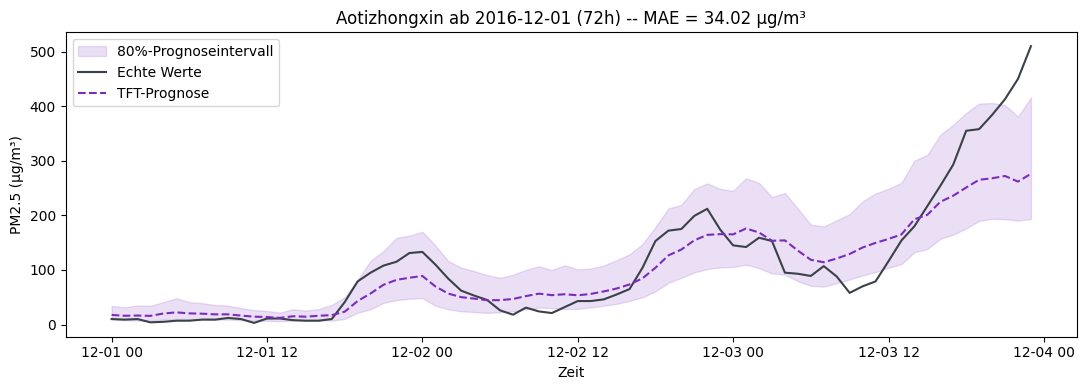

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


MAE (Aotizhongxin, ab 2016-12-01, 72h): 34.017 µg/m³


Predicting: |          | 0/? [00:00<?, ?it/s]

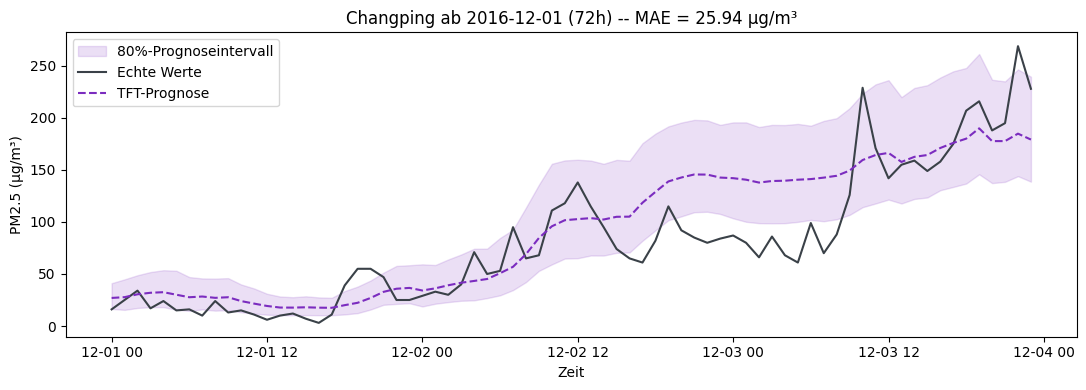

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


MAE (Changping, ab 2016-12-01, 72h): 25.942 µg/m³


Predicting: |          | 0/? [00:00<?, ?it/s]

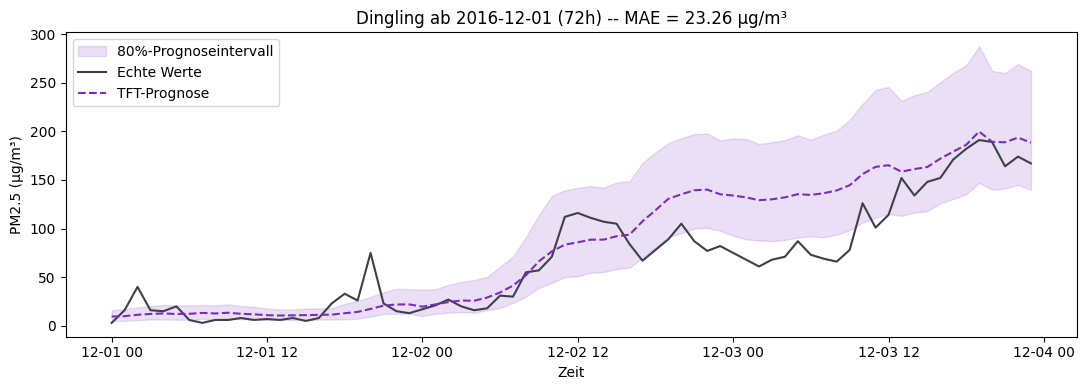

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


MAE (Dingling, ab 2016-12-01, 72h): 23.265 µg/m³


Predicting: |          | 0/? [00:00<?, ?it/s]

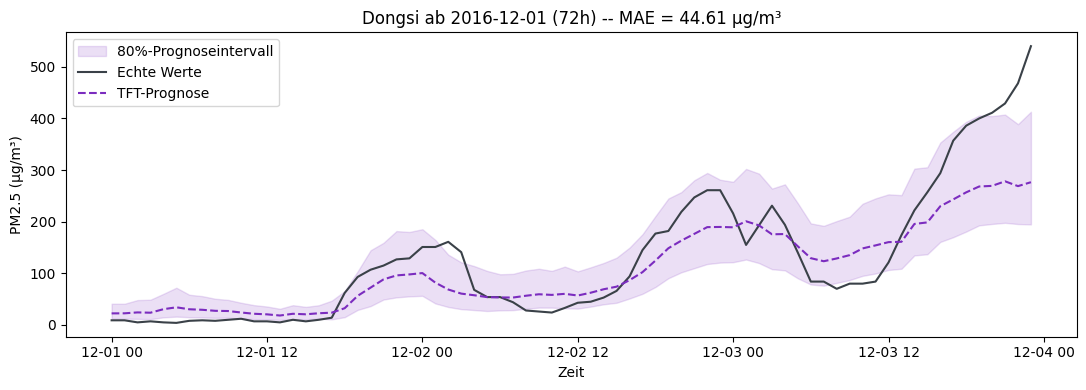

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


MAE (Dongsi, ab 2016-12-01, 72h): 44.608 µg/m³


Predicting: |          | 0/? [00:00<?, ?it/s]

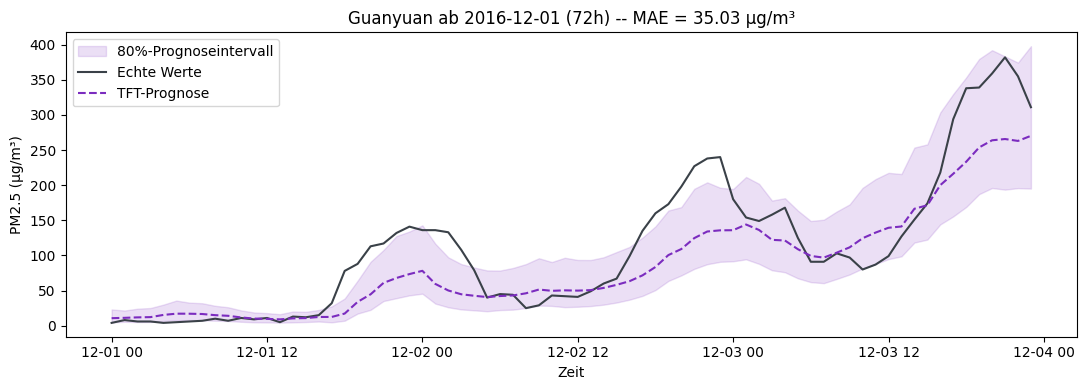

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


MAE (Guanyuan, ab 2016-12-01, 72h): 35.034 µg/m³


Predicting: |          | 0/? [00:00<?, ?it/s]

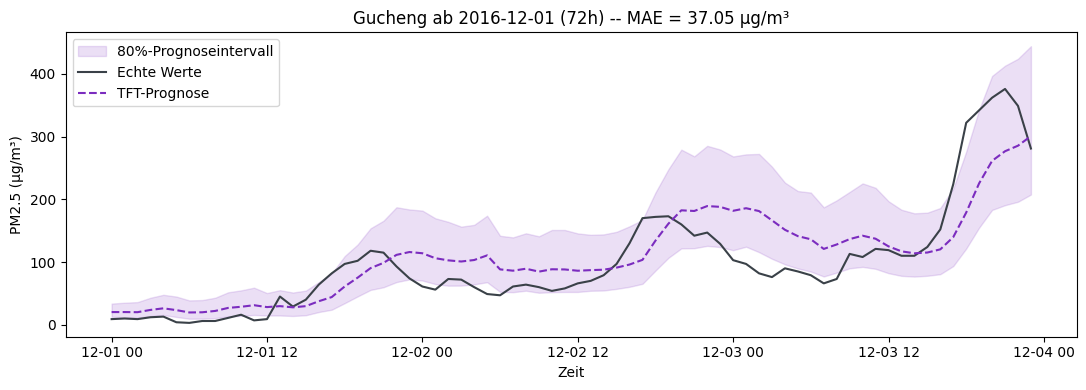

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


MAE (Gucheng, ab 2016-12-01, 72h): 37.052 µg/m³


Predicting: |          | 0/? [00:00<?, ?it/s]

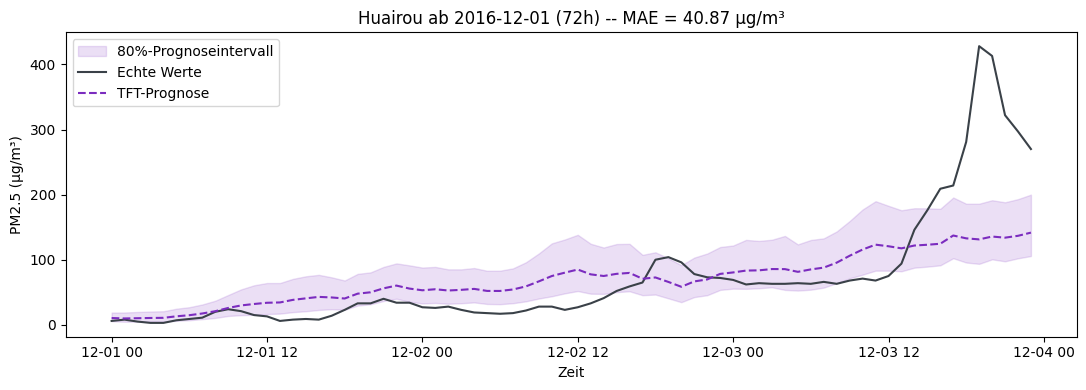

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


MAE (Huairou, ab 2016-12-01, 72h): 40.871 µg/m³


Predicting: |          | 0/? [00:00<?, ?it/s]

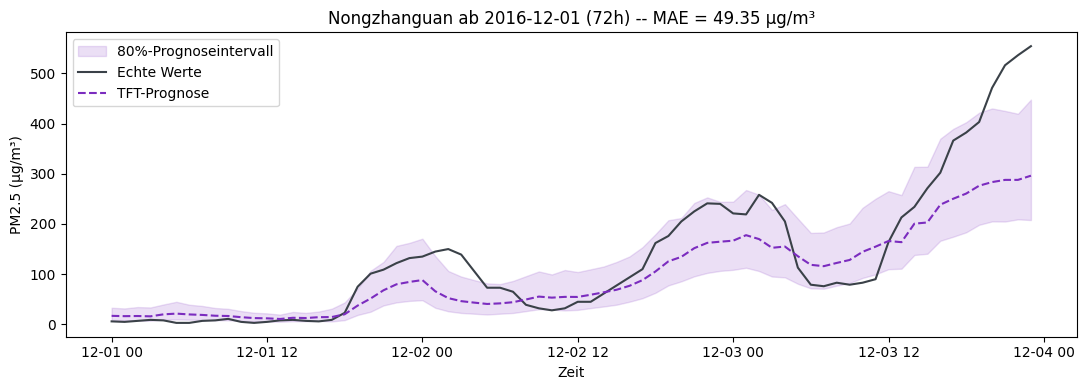

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


MAE (Nongzhanguan, ab 2016-12-01, 72h): 49.349 µg/m³


Predicting: |          | 0/? [00:00<?, ?it/s]

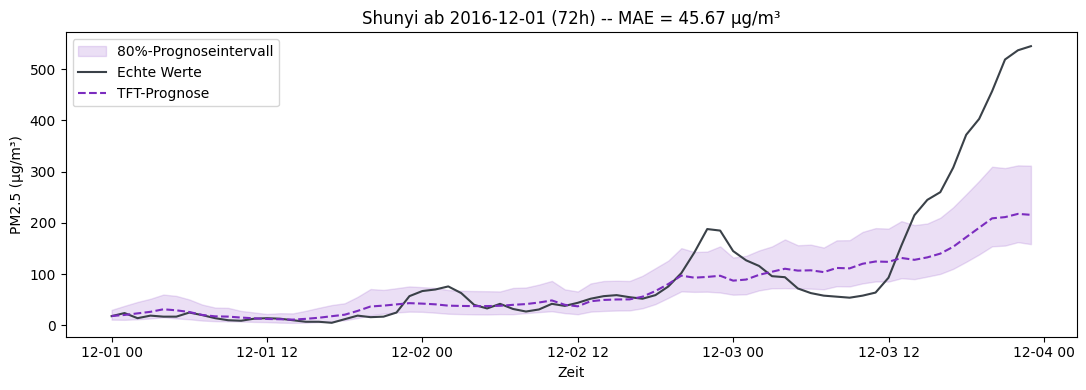

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


MAE (Shunyi, ab 2016-12-01, 72h): 45.670 µg/m³


Predicting: |          | 0/? [00:00<?, ?it/s]

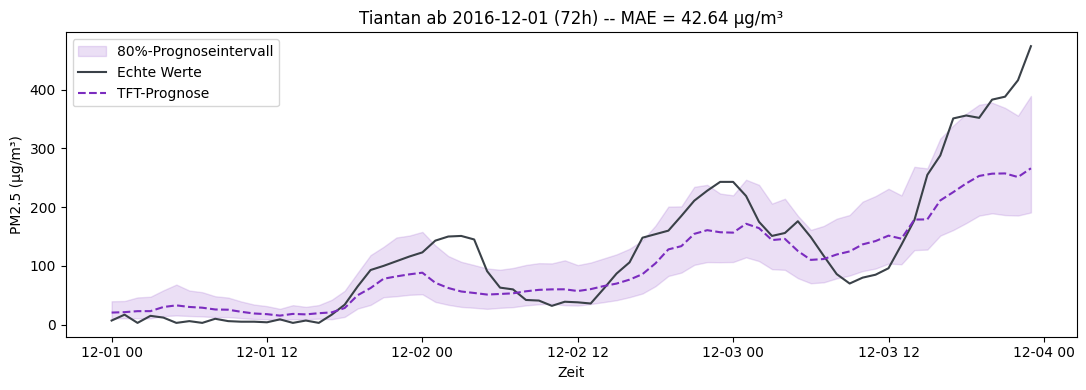

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


MAE (Tiantan, ab 2016-12-01, 72h): 42.641 µg/m³


Predicting: |          | 0/? [00:00<?, ?it/s]

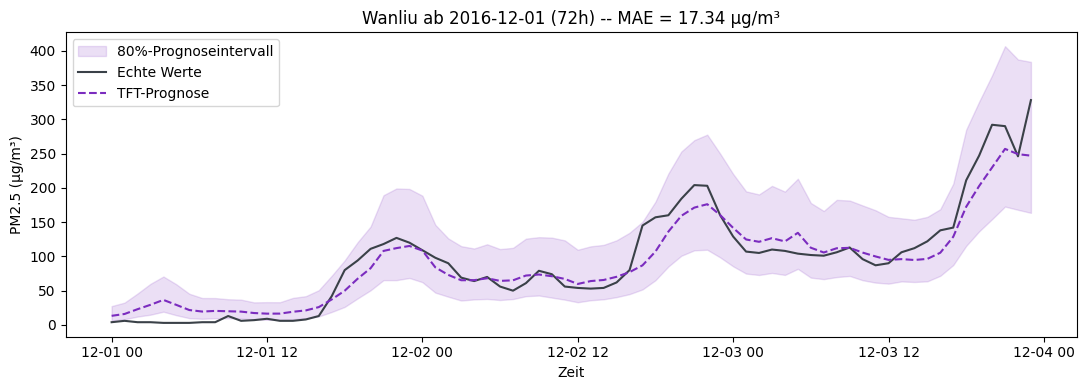

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


MAE (Wanliu, ab 2016-12-01, 72h): 17.342 µg/m³


Predicting: |          | 0/? [00:00<?, ?it/s]

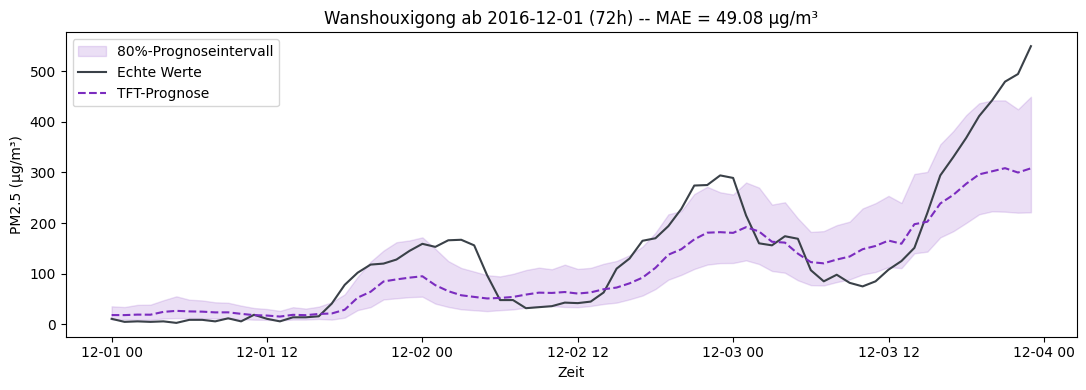

MAE (Wanshouxigong, ab 2016-12-01, 72h): 49.075 µg/m³


In [14]:
for station in STATIONEN_TEST:
    _ = vergleiche_tft(station, split_datum='2016-12-01', horizont=72)

In [ ]:
# Einzelner Aufruf fuer eine bestimmte Station/Zeitraum:
# vergleich_df, mae_wert = vergleiche_tft('Dongsi', split_datum='2016-11-01', horizont=72)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

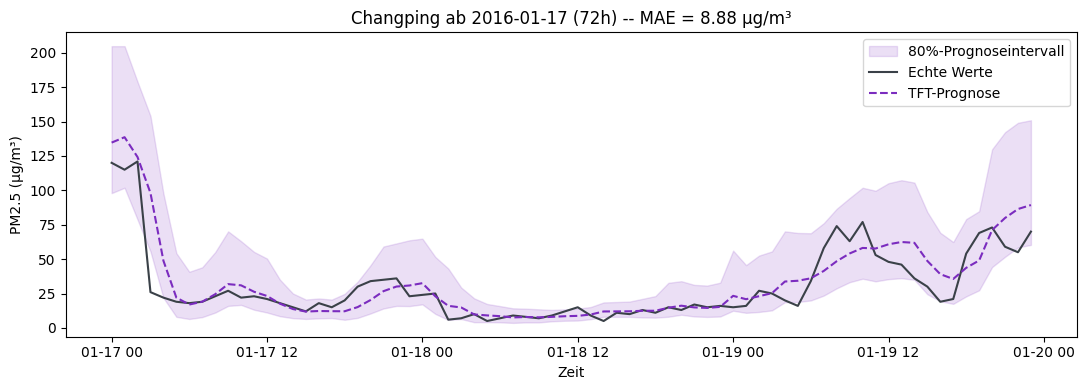

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


MAE (Changping, ab 2016-01-17, 72h): 8.877 µg/m³


Predicting: |          | 0/? [00:00<?, ?it/s]

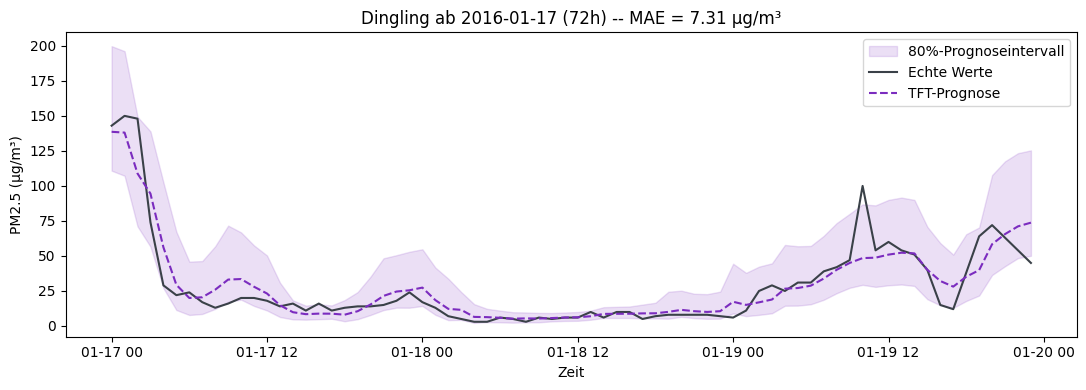

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


MAE (Dingling, ab 2016-01-17, 72h): 7.305 µg/m³


Predicting: |          | 0/? [00:00<?, ?it/s]

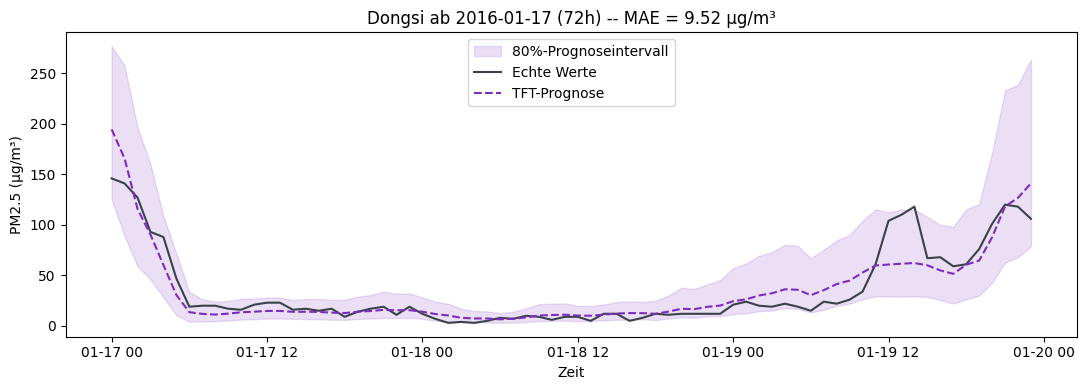

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


MAE (Dongsi, ab 2016-01-17, 72h): 9.525 µg/m³


Predicting: |          | 0/? [00:00<?, ?it/s]

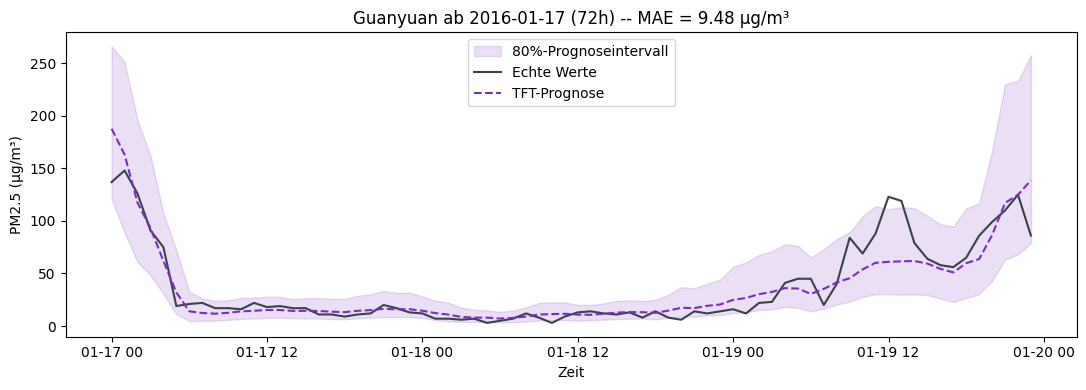

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


MAE (Guanyuan, ab 2016-01-17, 72h): 9.482 µg/m³


Predicting: |          | 0/? [00:00<?, ?it/s]

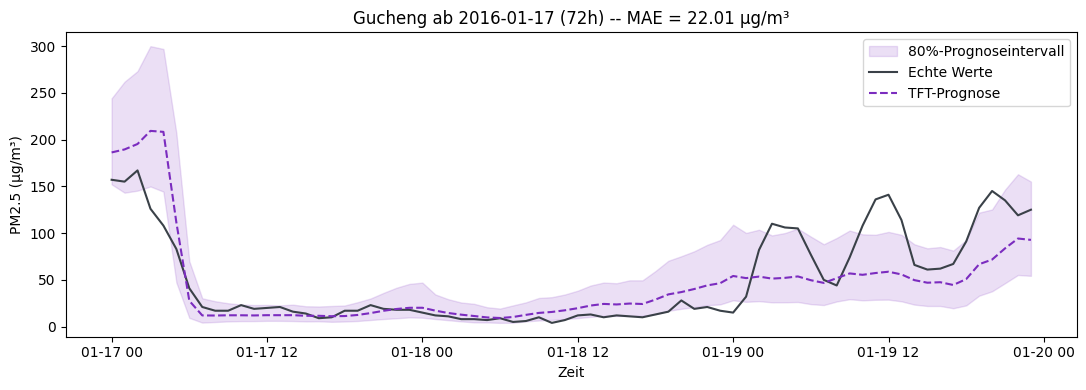

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


MAE (Gucheng, ab 2016-01-17, 72h): 22.006 µg/m³


Predicting: |          | 0/? [00:00<?, ?it/s]

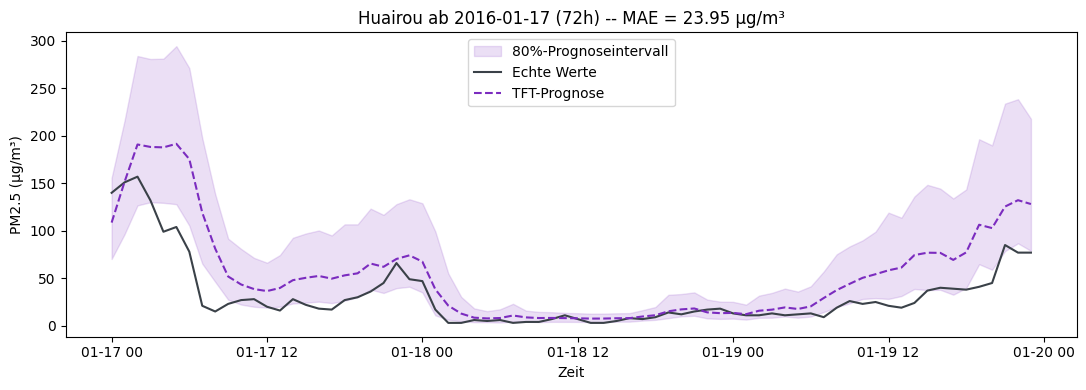

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


MAE (Huairou, ab 2016-01-17, 72h): 23.948 µg/m³


Predicting: |          | 0/? [00:00<?, ?it/s]

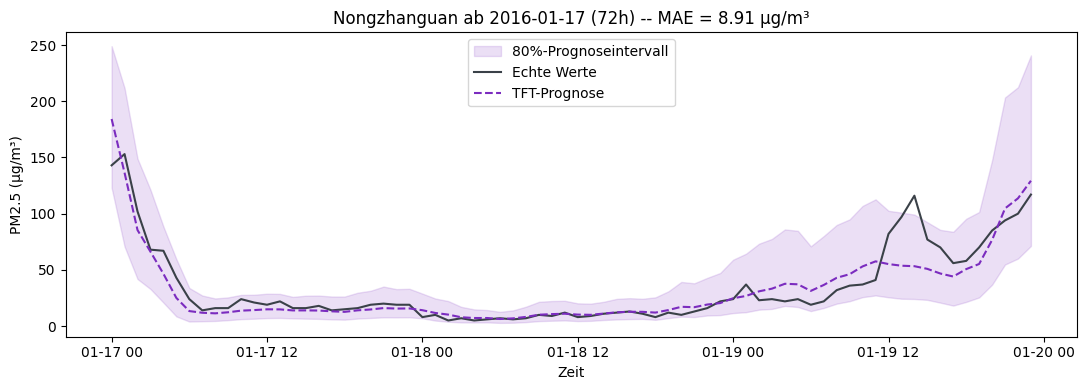

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


MAE (Nongzhanguan, ab 2016-01-17, 72h): 8.910 µg/m³


Predicting: |          | 0/? [00:00<?, ?it/s]

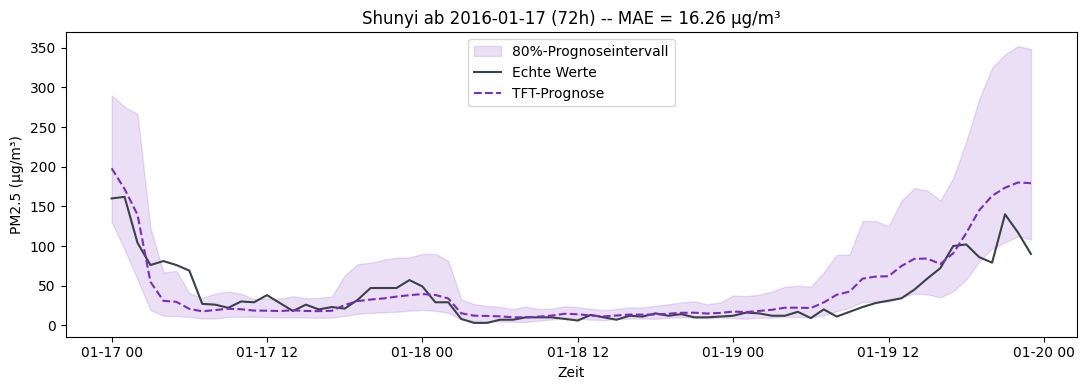

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


MAE (Shunyi, ab 2016-01-17, 72h): 16.262 µg/m³


Predicting: |          | 0/? [00:00<?, ?it/s]

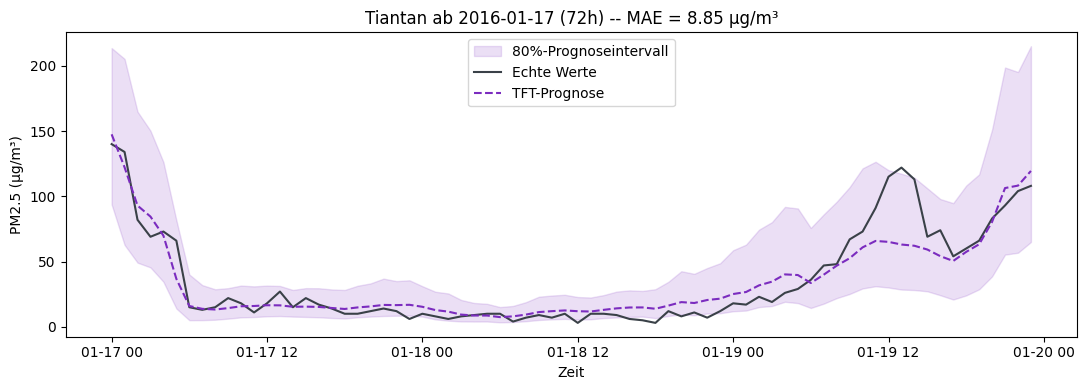

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


MAE (Tiantan, ab 2016-01-17, 72h): 8.854 µg/m³


Predicting: |          | 0/? [00:00<?, ?it/s]

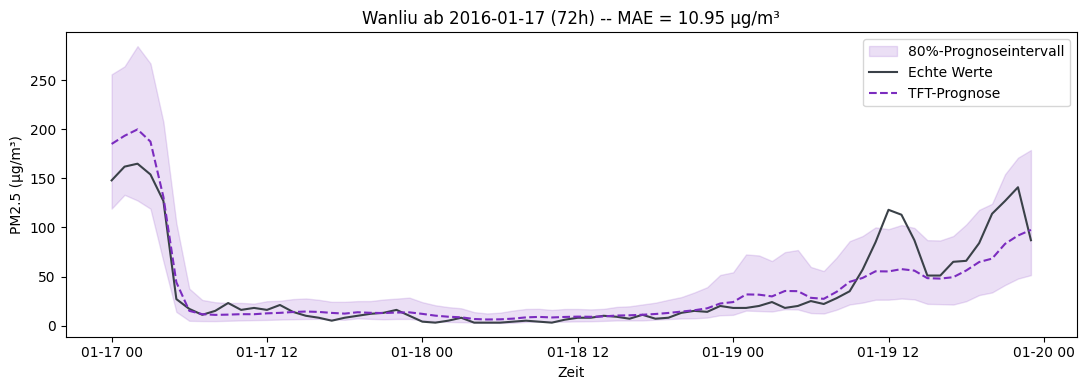

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


MAE (Wanliu, ab 2016-01-17, 72h): 10.948 µg/m³


Predicting: |          | 0/? [00:00<?, ?it/s]

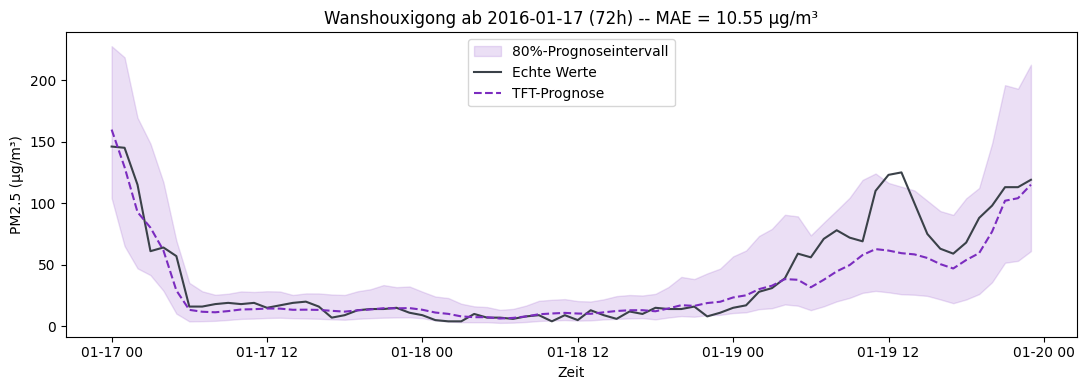

MAE (Wanshouxigong, ab 2016-01-17, 72h): 10.548 µg/m³


In [18]:
for station in STATIONEN_TEST:
    _ = vergleiche_tft(station, split_datum='2016-01-17', horizont=72)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

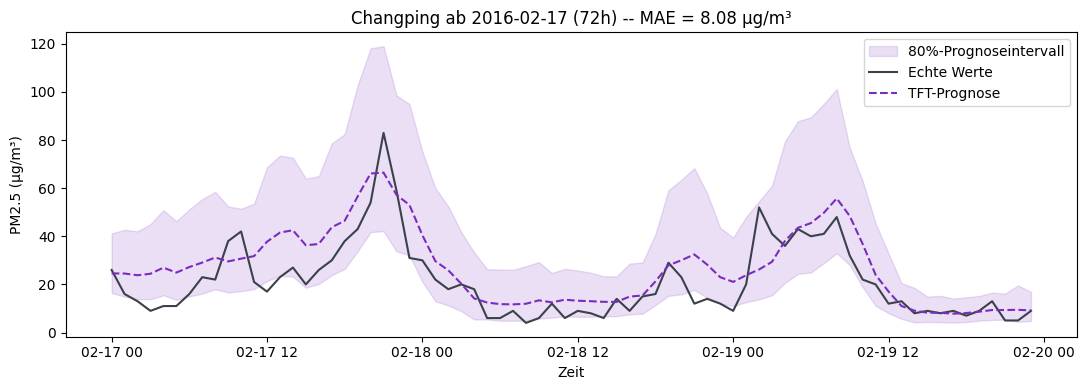

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


MAE (Changping, ab 2016-02-17, 72h): 8.078 µg/m³


Predicting: |          | 0/? [00:00<?, ?it/s]

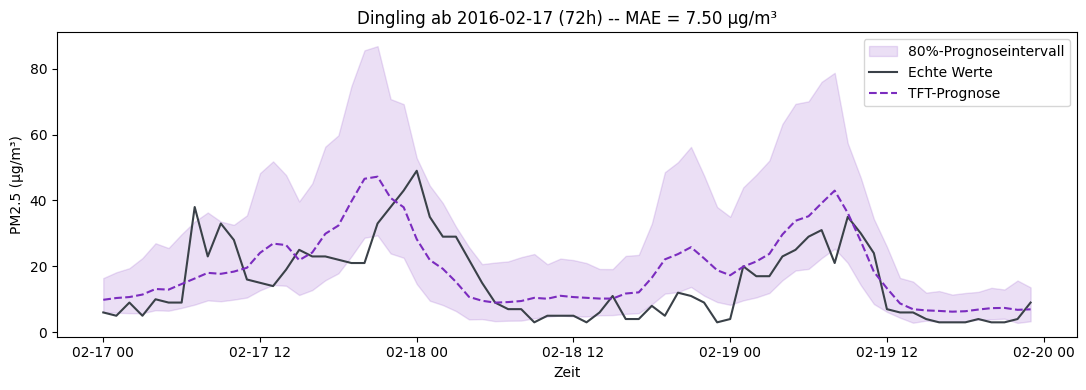

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


MAE (Dingling, ab 2016-02-17, 72h): 7.499 µg/m³


Predicting: |          | 0/? [00:00<?, ?it/s]

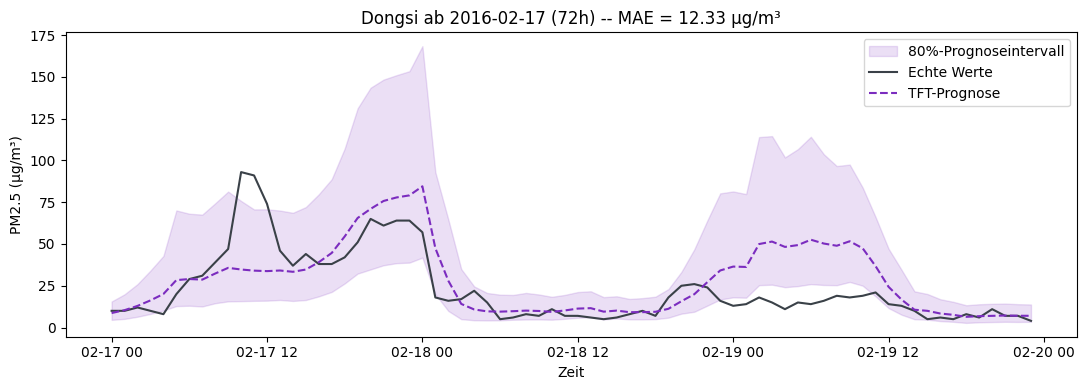

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


MAE (Dongsi, ab 2016-02-17, 72h): 12.333 µg/m³


Predicting: |          | 0/? [00:00<?, ?it/s]

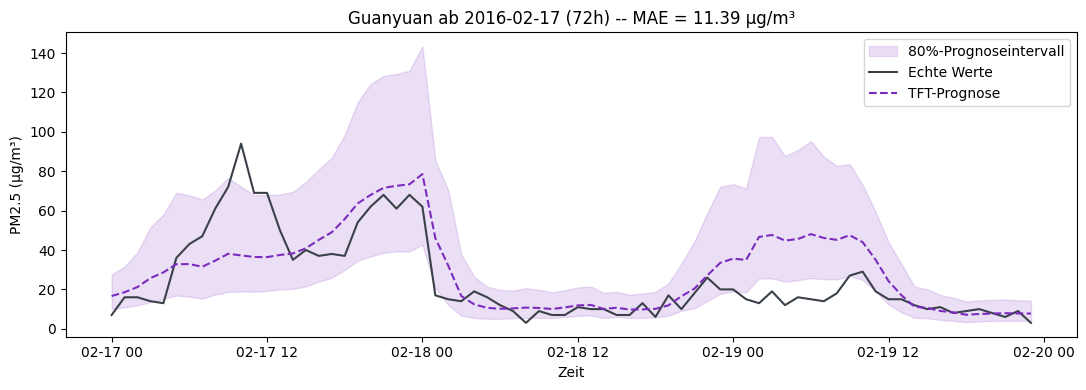

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


MAE (Guanyuan, ab 2016-02-17, 72h): 11.387 µg/m³


Predicting: |          | 0/? [00:00<?, ?it/s]

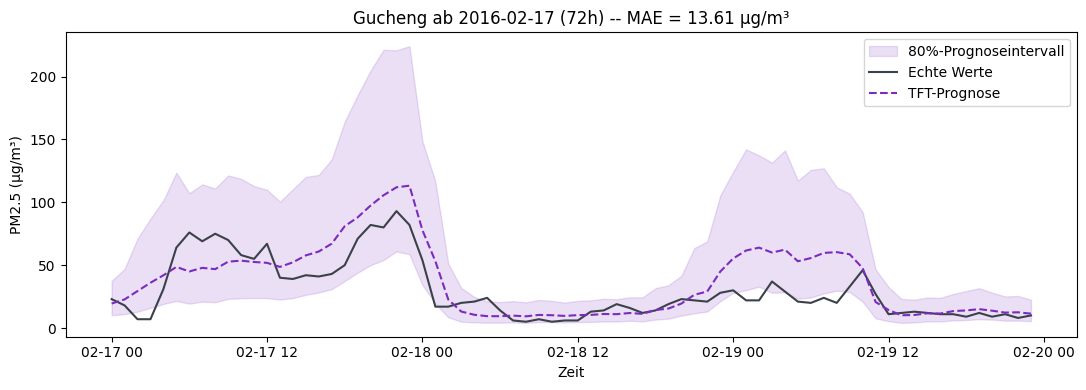

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


MAE (Gucheng, ab 2016-02-17, 72h): 13.615 µg/m³


Predicting: |          | 0/? [00:00<?, ?it/s]

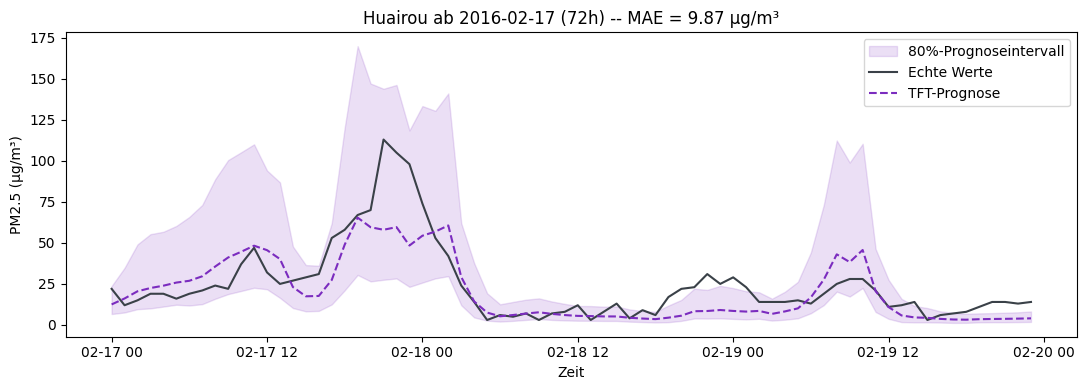

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


MAE (Huairou, ab 2016-02-17, 72h): 9.874 µg/m³


Predicting: |          | 0/? [00:00<?, ?it/s]

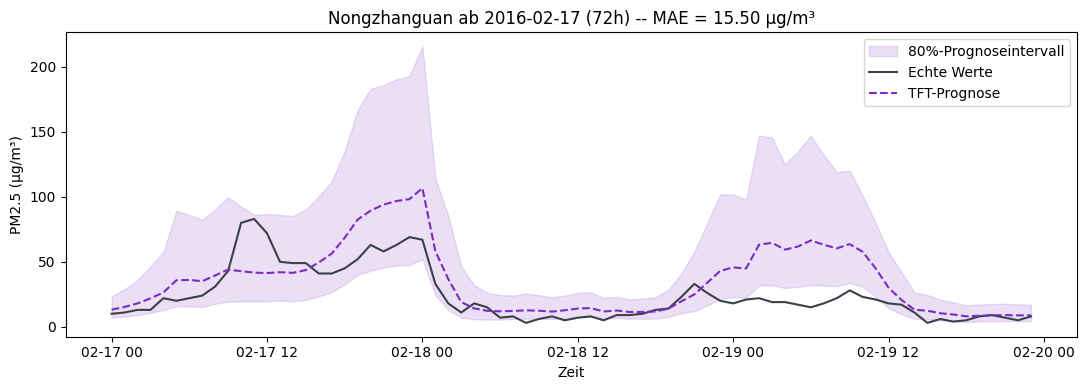

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


MAE (Nongzhanguan, ab 2016-02-17, 72h): 15.495 µg/m³


Predicting: |          | 0/? [00:00<?, ?it/s]

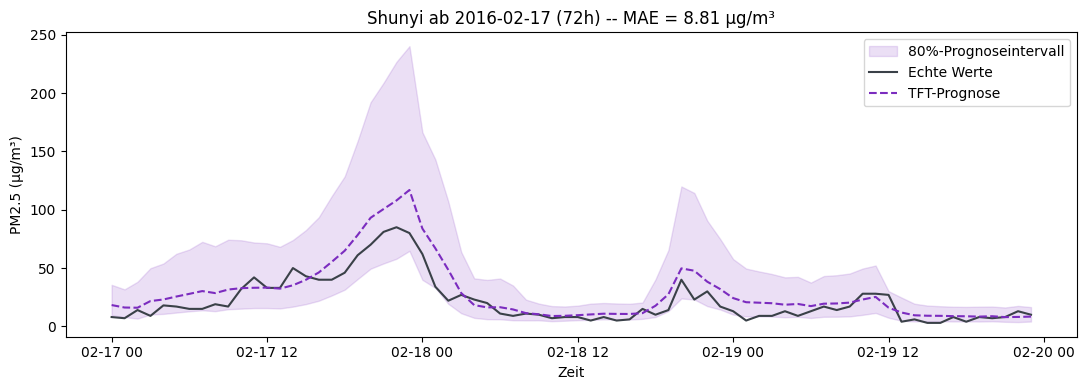

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


MAE (Shunyi, ab 2016-02-17, 72h): 8.809 µg/m³


Predicting: |          | 0/? [00:00<?, ?it/s]

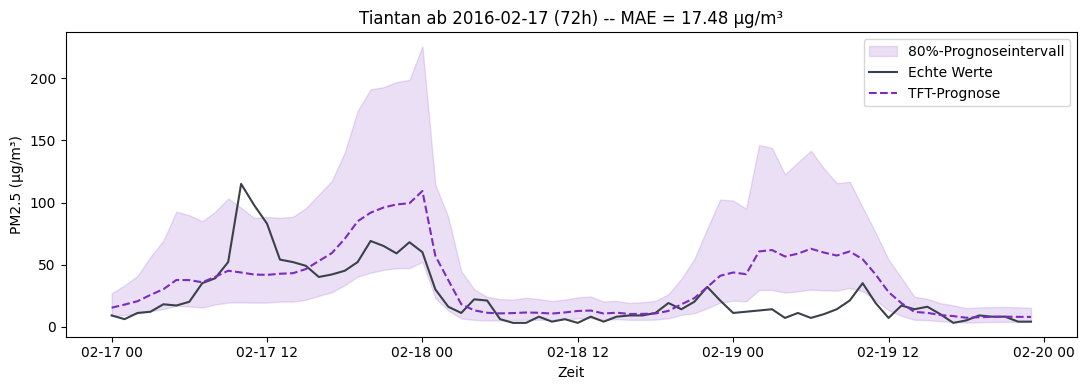

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


MAE (Tiantan, ab 2016-02-17, 72h): 17.480 µg/m³


Predicting: |          | 0/? [00:00<?, ?it/s]

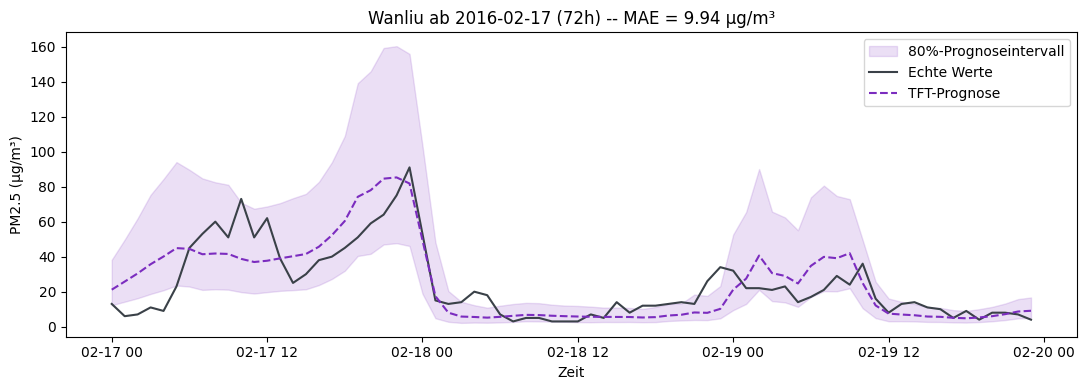

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


MAE (Wanliu, ab 2016-02-17, 72h): 9.939 µg/m³


Predicting: |          | 0/? [00:00<?, ?it/s]

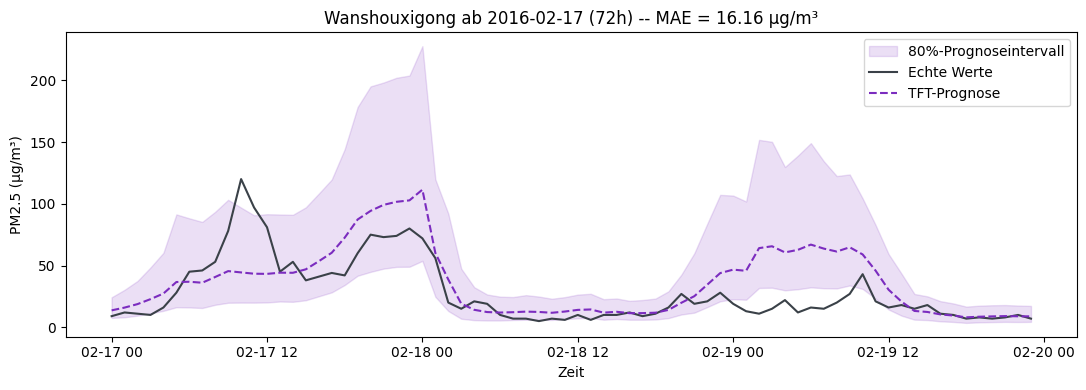

MAE (Wanshouxigong, ab 2016-02-17, 72h): 16.156 µg/m³


In [21]:
for station in STATIONEN_TEST:
    _ = vergleiche_tft(station, split_datum='2016-02-17', horizont=72)

## 7. Modellvergleich: `tft_final_multivariat` vs. `tft_final_multivariat_v2`

Laedt beide gespeicherten Modelle unabhaengig von `nf` oben (das oben geladene Modell bleibt
unangetastet) und vergleicht sie zunaechst anhand ihrer **Hyperparameter**.

Beide Modelle wurden auf `ALLE_STATIONEN` (alle 11 Stationen) trainiert -- der Performance-Vergleich
in Abschnitt 8 lauft also auf denselben Stationen, die auch beim Training verwendet wurden.

In [12]:
MODELL_DIR_A = Path('../models/tft_final_multivariat')
MODELL_DIR_B = Path('../models/tft_final_multivariat_v2')

for p in (MODELL_DIR_A, MODELL_DIR_B):
    assert p.exists(), f'Modell-Ordner {p} nicht gefunden -- Pfad pruefen.'

nf_a = NeuralForecast.load(path=str(MODELL_DIR_A))
nf_b = NeuralForecast.load(path=str(MODELL_DIR_B))

tft_a = nf_a.models[0]
tft_b = nf_b.models[0]

print(f'Modell A geladen: {MODELL_DIR_A}')
print(f'Modell B geladen: {MODELL_DIR_B}')

Seed set to 1
Seed set to 1


Modell A geladen: ..\models\tft_final_multivariat
Modell B geladen: ..\models\tft_final_multivariat_v2


In [13]:
hp_a = dict(tft_a.hparams)
hp_b = dict(tft_b.hparams)

alle_keys = sorted(set(hp_a) | set(hp_b))
zeilen = []
for k in alle_keys:
    va = hp_a.get(k, '—')
    vb = hp_b.get(k, '—')
    zeilen.append({
        'Parameter': k,
        MODELL_DIR_A.name: va,
        MODELL_DIR_B.name: vb,
        'unterschiedlich': str(va) != str(vb),
    })

parameter_vergleich = pd.DataFrame(zeilen)

print('Alle Hyperparameter:')
print(parameter_vergleich.drop(columns='unterschiedlich').to_string(index=False))

print('\nNur unterschiedliche Parameter:')
diff = parameter_vergleich[parameter_vergleich['unterschiedlich']].drop(columns='unterschiedlich')
if diff.empty:
    print('(keine Unterschiede gefunden)')
else:
    print(diff.to_string(index=False))

Alle Hyperparameter:
                           Parameter                                                                          tft_final_multivariat                                                                       tft_final_multivariat_v2
                         accelerator                                                                                            gpu                                                                                            gpu
                               alias                                                                                           None                                                                                           None
                        attn_dropout                                                                                            0.0                                                                                       0.136821
                          batch_size                                   

## 8. Modellvergleich: Performance auf `ALLE_STATIONEN`, 01.09.2016 -- 28.02.2017, 13-Tage-Schritte

Walk-Forward-Auswertung fuer beide Modelle auf denselben Cutoff-Zeitpunkten (alle 13 Tage), fuer die
Horizonte `HORIZONTE = [8, 24, 48, 72]`. Nutzt ausschliesslich `nf.predict()` -- kein Training.

In [13]:
EVAL_START   = pd.Timestamp('2016-09-01')
EVAL_END     = pd.Timestamp('2017-02-28')
EVAL_SCHRITT = pd.Timedelta(days=13)

STATIONEN_VERGLEICH = ALLE_STATIONEN   # beide Modelle wurden auf allen Stationen trainiert
print(f'{len(STATIONEN_VERGLEICH)} Stationen: {STATIONEN_VERGLEICH}')

def baue_multi(stationen):
    '''Baut ein multi-DataFrame (regularisiert, log-transformiert, standardisiert) fuer die
    uebergebenen Stationen -- unabhaengig von den frueher geladenen multi/skalen/DATENENDE, damit
    diese fuer die Einzelstations-Beispiele oben unveraendert bleiben.'''
    teile = []
    skalen_lokal = {}
    letzte_ds = []
    for st in stationen:
        d = lade_gesamt(st)
        d = regularize(d, spalten=alle_spalten)
        d = add_time_features(d)
        d = add_feiertag(d)
        d = d[['ds'] + alle_spalten + KALENDER_REGRESSOREN].copy()
        d.insert(0, 'unique_id', st)
        train_maske = d['ds'] < pd.Timestamp(TRAIN_CUTOFF)
        skalen_lokal[st] = mase_skala(d.loc[train_maske, 'y'])
        letzte_ds.append(d['ds'].max())
        teile.append(d)

    m = pd.concat(teile, ignore_index=True)
    datenende_lokal = min(letzte_ds)
    m = m[m['ds'] <= datenende_lokal].reset_index(drop=True)

    m['y_original'] = m['y']
    m['y'] = np.log1p(m['y'])

    train_maske = m['ds'] < pd.Timestamp(TRAIN_CUTOFF)
    scaler_lokal = StandardScaler()
    scaler_lokal.fit(m.loc[train_maske, REGRESSOREN_ZU_SKALIEREN])
    m[REGRESSOREN_ZU_SKALIEREN] = scaler_lokal.transform(m[REGRESSOREN_ZU_SKALIEREN])
    return m, skalen_lokal, datenende_lokal

multi_alle, skalen_alle, DATENENDE_alle = baue_multi(STATIONEN_VERGLEICH)

stat_df_alle = pd.DataFrame({
    'unique_id': STATIONEN_VERGLEICH,
    'stationstyp': [float(STATIONSTYP_CODE[STATIONSTYP_TEXT[s]]) for s in STATIONEN_VERGLEICH],
})

print(f'Gemeinsames Datenende ({len(STATIONEN_VERGLEICH)} Stationen): {DATENENDE_alle}')
benoetigt_bis = EVAL_END + pd.Timedelta(hours=max(HORIZONTE))
if benoetigt_bis > DATENENDE_alle:
    print(f'⚠️  Achtung: fuer den letzten Horizont ({max(HORIZONTE)}h) am {EVAL_END.date()} werden '
         f'Daten bis {benoetigt_bis} gebraucht, verfuegbar sind aber nur bis {DATENENDE_alle}. '
         f'Die letzten Cutoffs werden entsprechend uebersprungen (siehe Fensteranzahl unten).')

11 Stationen: ['Changping', 'Dingling', 'Dongsi', 'Guanyuan', 'Gucheng', 'Huairou', 'Nongzhanguan', 'Shunyi', 'Tiantan', 'Wanliu', 'Wanshouxigong']
Gemeinsames Datenende (11 Stationen): 2017-02-28 23:00:00
⚠️  Achtung: fuer den letzten Horizont (72h) am 2017-02-28 werden Daten bis 2017-03-03 00:00:00 gebraucht, verfuegbar sind aber nur bis 2017-02-28 23:00:00. Die letzten Cutoffs werden entsprechend uebersprungen (siehe Fensteranzahl unten).


In [14]:
def walk_forward_vergleich(nf, multi, stat_df, skalen, stationen, start, end, schritt, horizonte,
                            modellname=''):
    '''Walk-Forward-Auswertung eines geladenen NeuralForecast-Modells `nf` auf `multi`/`stat_df`
    zwischen `start` und `end` in `schritt`-Abstaenden, fuer alle `horizonte` (in Stunden).
    Gibt (ergebnis_df, cv_df) zurueck.'''
    h_max = max(horizonte)

    cutoffs = []
    t = start
    letzter_verfuegbarer_zeitpunkt = min(end, multi['ds'].max())
    while t + pd.Timedelta(hours=h_max) <= letzter_verfuegbarer_zeitpunkt:
        cutoffs.append(t)
        t += schritt
    print(f'[{modellname}] {len(cutoffs)} Walk-Forward-Fenster von {start.date()} bis {end.date()} '
         f'(Schritt: {schritt.days} Tage)')

    alle_vorhersagen = []
    for i, cutoff in enumerate(cutoffs):
        kontext_start = cutoff - pd.Timedelta(hours=INPUT_SIZE + 24)
        kontext_df = multi[(multi['unique_id'].isin(stationen)) &
                           (multi['ds'] >= kontext_start) & (multi['ds'] < cutoff)]
        fenster = multi[(multi['unique_id'].isin(stationen)) &
                        (multi['ds'] >= cutoff) & (multi['ds'] < cutoff + pd.Timedelta(hours=h_max))]
        if fenster.empty or fenster['unique_id'].nunique() < len(stationen):
            continue

        futr_df = fenster[['unique_id', 'ds'] + REGRESSOREN_ZUKUNFT]
        pred = nf.predict(df=kontext_df, static_df=stat_df, futr_df=futr_df)
        pred['yhat'] = np.expm1(pred['TFT-median']).clip(lower=0)
        pred['cutoff'] = cutoff

        echte = fenster[['unique_id', 'ds', 'y_original']].rename(columns={'y_original': 'y'})
        vergleich = echte.merge(pred[['unique_id', 'ds', 'cutoff', 'yhat']], on=['unique_id', 'ds'])
        alle_vorhersagen.append(vergleich)

        if (i + 1) % 5 == 0 or i == len(cutoffs) - 1:
            print(f'  [{modellname}] Fenster {i+1}/{len(cutoffs)} ({cutoff.date()}) erledigt')

    if not alle_vorhersagen:
        raise ValueError('Keine Vorhersagen erzeugt -- Zeitraum/Datenverfuegbarkeit pruefen.')

    cv = pd.concat(alle_vorhersagen, ignore_index=True)
    cv['lead'] = ((cv['ds'] - cv['cutoff']).dt.total_seconds() // 3600).astype(int)

    rows = []
    for b in horizonte:
        w = cv[cv['lead'] <= b]
        per_station = [{'MAE': mae(g['y'], g['yhat']), 'RMSE': rmse(g['y'], g['yhat']),
                        'MASE': mae(g['y'], g['yhat']) / skalen[st], 'MAPE %': mape(g['y'], g['yhat'])}
                       for st, g in w.groupby('unique_id')]
        m = pd.DataFrame(per_station).mean()
        rows.append({'Horizont': f'{b} h', 'MAE': m['MAE'], 'RMSE': m['RMSE'],
                     'MASE': m['MASE'], 'MAPE %': m['MAPE %']})

    ergebnis = pd.DataFrame(rows)[['Horizont', 'MAE', 'RMSE', 'MASE', 'MAPE %']].round(3)
    return ergebnis, cv

In [15]:
print('=== Modell A:', MODELL_DIR_A.name, '===')
ergebnis_a, cv_a = walk_forward_vergleich(
    nf_a, multi_alle, stat_df_alle, skalen_alle, STATIONEN_VERGLEICH,
    EVAL_START, EVAL_END, EVAL_SCHRITT, HORIZONTE, modellname=MODELL_DIR_A.name,
)
ergebnis_a.insert(0, 'Modell', MODELL_DIR_A.name)

print('\n=== Modell B:', MODELL_DIR_B.name, '===')
ergebnis_b, cv_b = walk_forward_vergleich(
    nf_b, multi_alle, stat_df_alle, skalen_alle, STATIONEN_VERGLEICH,
    EVAL_START, EVAL_END, EVAL_SCHRITT, HORIZONTE, modellname=MODELL_DIR_B.name,
)
ergebnis_b.insert(0, 'Modell', MODELL_DIR_B.name)

modellvergleich = pd.concat([ergebnis_a, ergebnis_b], ignore_index=True)
print('\n--- Ergebnis: alle Stationen zusammen ---')
print(modellvergleich.to_string(index=False))

VERGLEICH_CSV = Path('../data/modellvergleich_tft_final_v1_v2.csv')
VERGLEICH_CSV.parent.mkdir(parents=True, exist_ok=True)
modellvergleich.to_csv(VERGLEICH_CSV, index=False)
print(f'\ngespeichert -> {VERGLEICH_CSV}')

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


=== Modell A: tft_final_multivariat ===
[tft_final_multivariat] 14 Walk-Forward-Fenster von 2016-09-01 bis 2017-02-28 (Schritt: 13 Tage)


Predicting: |          | 0/? [00:00<?, ?it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

...

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

  [tft_final_multivariat_v2] Fenster 14/14 (2017-02-17) erledigt

--- Ergebnis: alle Stationen zusammen ---
                  Modell Horizont    MAE   RMSE  MASE  MAPE %
   tft_final_multivariat      8 h 25.498 48.969 0.453  57.766
   tft_final_multivariat     24 h 29.629 55.585 0.526  57.897
   tft_final_multivariat     48 h 29.598 53.342 0.527  67.546
   tft_final_multivariat     72 h 33.685 57.810 0.598  72.350
tft_final_multivariat_v2      8 h 22.160 40.567 0.394  64.420
tft_final_multivariat_v2     24 h 27.078 47.295 0.482  67.704
tft_final_multivariat_v2     48 h 28.213 46.785 0.503  82.417
tft_final_multivariat_v2     72 h 30.216 48.700 0.538  82.519

gespeichert -> ..\data\modellvergleich_tft_final_v1_v2.csv


### 8b. Direktvergleich pro Horizont (Pivot) + Plot

Zeigt die MAE-Differenz zwischen beiden Modellen je Horizont und stellt sie grafisch gegenueber.

Modell    tft_final_multivariat  tft_final_multivariat_v2  Differenz (A - B)
Horizont                                                                    
8 h                      25.498                    22.160              3.338
24 h                     29.629                    27.078              2.551
48 h                     29.598                    28.213              1.385
72 h                     33.685                    30.216              3.469


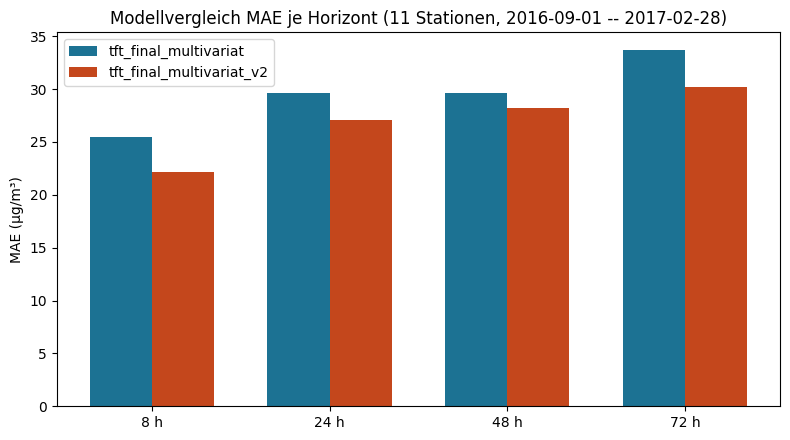

In [16]:
pivot = modellvergleich.pivot(index='Horizont', columns='Modell', values='MAE')
pivot = pivot.reindex([f'{b} h' for b in HORIZONTE])   # in HORIZONTE-Reihenfolge sortieren
pivot['Differenz (A - B)'] = pivot[MODELL_DIR_A.name] - pivot[MODELL_DIR_B.name]
print(pivot.round(3).to_string())

plt.figure(figsize=(8, 4.5))
x = np.arange(len(HORIZONTE))
breite = 0.35
plt.bar(x - breite/2, pivot[MODELL_DIR_A.name], width=breite, label=MODELL_DIR_A.name, color='#1C7293')
plt.bar(x + breite/2, pivot[MODELL_DIR_B.name], width=breite, label=MODELL_DIR_B.name, color='#C4471C')
plt.xticks(x, [f'{b} h' for b in HORIZONTE])
plt.ylabel('MAE (µg/m³)')
plt.title(f'Modellvergleich MAE je Horizont ({STATIONEN_VERGLEICH.__len__()} Stationen, '
         f'{EVAL_START.date()} -- {EVAL_END.date()})')
plt.legend(loc='best'); plt.tight_layout(); plt.show()

### 8c. Aufschluesselung je Station (optional)

Zeigt MAE je Station und Horizont fuer beide Modelle getrennt.

In [17]:
def je_station(cv, skalen, horizonte, modellname):
    rows = []
    for b in horizonte:
        w = cv[cv['lead'] <= b]
        for st, g in w.groupby('unique_id'):
            rows.append({
                'Modell': modellname, 'Station': st, 'Horizont': f'{b} h',
                'MAE': mae(g['y'], g['yhat']), 'MASE': mae(g['y'], g['yhat']) / skalen[st],
            })
    return pd.DataFrame(rows)

je_station_df = pd.concat([
    je_station(cv_a, skalen_alle, HORIZONTE, MODELL_DIR_A.name),
    je_station(cv_b, skalen_alle, HORIZONTE, MODELL_DIR_B.name),
], ignore_index=True)

print('MAE je Station/Horizont (Ausschnitt):')
print(je_station_df.sort_values(['Modell', 'Horizont', 'MAE']).to_string(index=False))

# Station mit dem groessten Unterschied zwischen den Modellen je Horizont:
pivot_station = je_station_df.pivot_table(index=['Horizont', 'Station'], columns='Modell', values='MAE')
pivot_station['Differenz (A - B)'] = pivot_station.iloc[:, 0] - pivot_station.iloc[:, 1]
print('\nGroesste Unterschiede zwischen den Modellen (nach |Differenz| sortiert):')
print(pivot_station.reindex(pivot_station['Differenz (A - B)'].abs().sort_values(ascending=False).index).head(10).round(3))

MAE je Station/Horizont (Ausschnitt):
                  Modell       Station Horizont       MAE     MASE
   tft_final_multivariat     Changping     24 h 24.287938 0.472442
   tft_final_multivariat       Tiantan     24 h 24.515151 0.426928
   tft_final_multivariat  Nongzhanguan     24 h 26.615463 0.437592
   tft_final_multivariat      Dingling     24 h 27.730304 0.541968
   tft_final_multivariat Wanshouxigong     24 h 28.154473 0.466230
   tft_final_multivariat      Guanyuan     24 h 28.608806 0.504419
   tft_final_multivariat        Dongsi     24 h 28.658296 0.472443
   tft_final_multivariat       Gucheng     24 h 29.085454 0.510575
   tft_final_multivariat        Wanliu     24 h 31.170017 0.538027
   tft_final_multivariat       Huairou     24 h 32.433854 0.646439
   tft_final_multivariat        Shunyi     24 h 44.659640 0.773799
   tft_final_multivariat     Changping     48 h 21.339596 0.415092
   tft_final_multivariat       Tiantan     48 h 25.640345 0.446523
   tft_final_multivariat